In [47]:
# Data manipulation
import pandas as pd
import numpy as np

# Data extraction
import kagglehub

import os
import glob


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Timing
import time

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids
from imblearn.combine import SMOTETomek

# Feature Extraction
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import shap

# Data manipulation
from sklearn.model_selection import StratifiedShuffleSplit

# Misc
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid")

## Dataset Loading

Downloads and loads the Credit Card Fraud dataset.
If already present locally, it loads from disk instead of re-downloading

In [48]:
# Download latest version if it doesn't exist yet
dataset_key = "mlg-ulb/creditcardfraud"
csv_name = "creditcardfraud.csv"

if not os.path.exists(csv_name):
    path = kagglehub.dataset_download(dataset_key)
else:
    path = csv_name

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print(csv_files)
df = pd.read_csv(csv_files[0])

print("Dataset Shape:", df.shape)

df.head()

['C:\\Users\\Daniel\\.cache\\kagglehub\\datasets\\mlg-ulb\\creditcardfraud\\versions\\3\\creditcard.csv']
Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

Displays dataset structure, summary statistics, and checks for missing values to ensure data quality

In [49]:
print(df.info())
print(df.describe())

# Check for missing values
print("Missing Values:\n", df.isnull().sum()) 

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Class Distribution Analysis

Analyzes fraud vs non-fraud distribution to understand class imbalance and dataset skew

Class
0    284315
1       492
Name: count, dtype: int64


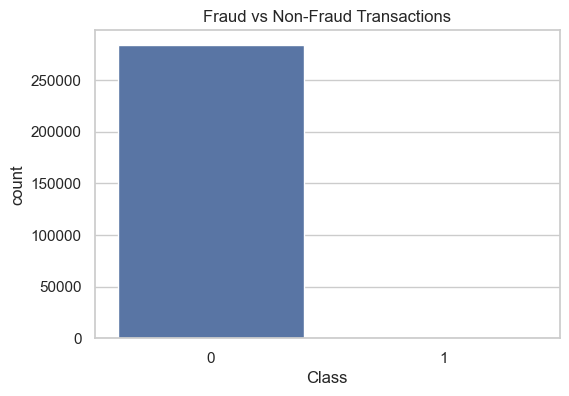

Fraud Percentage: 0.1727%


In [50]:
class_counts = df["Class"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

fraud_percentage = (
    df["Class"].sum() / len(df)
) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")


**Observations:**

1. Dataset contains **284,807 transactions**.
2. Fraud transactions represent only **0.1727%** of the dataset.



## Feature-Target Split

Separates dataset into features (X), target labels (y), and extracts feature names for interpretability in modeling and analysis

In [51]:
target_col = "Class"

y = df[target_col].values
X = df.drop(columns=[target_col]).values

feature_names = df.drop(columns=[target_col]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", len(feature_names))

X shape: (284807, 30)
y shape: (284807,)
Num features: 30


## Model Factory Function

Creates all classifiers used in the project for fraud detection under strong class imbalance.

We use multiple models to compare how different learning approaches behave under imbalanced data, where false negatives (missed fraud) are more costly than false positives.

To address this, we use **class weighting**, which increases the importance of fraud samples during training by scaling their contribution to the loss. This shifts models toward detecting fraud more aggressively.

---

### Models included

#### K-Nearest Neighbors (KNN)
- Baseline distance-based model
- No class weighting support
- Imbalance handled indirectly via scaling and threshold tuning

#### Logistic Regression
- Linear model with probability output
- Supports `class_weight`
- Trained with weighted loss to prioritize fraud detection

#### Random Forest
- Tree ensemble model
- Supports `class_weight`
- Uses weighted impurity in split decisions

#### AdaBoost
- Boosting ensemble model
- Uses `sample_weight` instead of `class_weight`
- Fraud samples are given higher weight during boosting to force focus on minority class

In [52]:
def create_models(random_state=42, class_weight=None):
    """
    Creates and returns all classifiers used in the project.
    class_weight: dict like {0:1, 1:10} or "balanced"
    """

    models = {
        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            random_state=random_state,
            class_weight=class_weight
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=random_state,
            n_jobs=-1,
            class_weight=class_weight
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            random_state=random_state
        )
    }

    return models

## Data Balancing Factory Function (Q1)

This function creates and returns all balancing techniques used to handle class imbalance in the dataset.

### Methods included:
- None (no balancing)
- Undersampling (RandomUnderSampler)
- SMOTE (Synthetic Minority Over-sampling Technique)
- SMOTE-Tomek (hybrid approach combining SMOTE and Tomek links)

In [53]:
def create_balancing_methods(random_state=42):

    return {
        "None": None,

        "Undersampling": RandomUnderSampler(
            random_state=random_state
        ),

        "SMOTE": SMOTE(
            random_state=random_state
        ),

        "SMOTE_Tomek": SMOTETomek(
            random_state=random_state
        ),
        "ClusterCentroids": ClusterCentroids(
            random_state=random_state
        )
    }

## Threshold Optimization for Recall Bias

In fraud detection, it is preferable to incorrectly flag a transaction as fraud
rather than miss an actual fraudulent transaction.

Therefore, we adjust the decision threshold of the model to prioritize recall.

Recall is defined as:

Recall = TP / (TP + FN)

By maximizing recall, we minimize false negatives (missed fraud cases),
which is critical in real-world fraud detection systems.

We therefore select the smallest threshold that satisfies a target recall,
making the classifier more sensitive to fraud predictions.

In [54]:
def find_threshold_for_target_recall(y_true, y_proba, target_recall=0.95):
    """
    Returns the lowest threshold that achieves target recall.
    If not achievable, returns the smallest possible threshold.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # align sizes (recall has +1 element vs thresholds)
    recall = recall[:-1]

    valid_idx = np.where(recall >= target_recall)[0]

    if len(valid_idx) > 0:
        # pick highest threshold that still satisfies recall
        best_idx = valid_idx[-1]
        return thresholds[best_idx]
    
    # fallback: most aggressive (catch everything)
    return thresholds[np.argmin(recall)]

## Apply Balancing To Data

Function to apply the balance methods to the data before running models

In [55]:
def apply_balancing(X_train, y_train, method):
    """
    Applies balancing ONLY on training data.
    """

    if method is None:
        return X_train, y_train

    X_res, y_res = method.fit_resample(X_train, y_train)

    return X_res, y_res

### Feature Importance Extraction (Q2+3)

This function extracts feature importance from trained models.

- Random Forest / AdaBoost → uses built-in `feature_importances_`
- Logistic Regression → uses absolute values of coefficients

Output:
A sorted table of features ranked by importance, showing how strongly each feature influences predictions.

In [56]:
def extract_feature_importance(model, feature_names):
    """
    Extracts feature importance from supported models:
    - RandomForest
    - AdaBoost
    - Logistic Regression

    Returns zeros if model does not support feature importance (KNN in this case).
    """

    importance = None

    # Tree-based models
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    # Linear models
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_).ravel()

    # fallback 
    else:
        importance = np.zeros(len(feature_names))

    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    return df.sort_values("importance", ascending=False).reset_index(drop=True)

### SHAP Feature Analysis

SHAP helps explaining model predictions by assigning each feature a contribution value.

- `compute_shap_values`: calculates SHAP values for each prediction
- `shap_global_importance`: aggregates SHAP values into global feature importance

Output:
- Local explanations (per prediction)
- Global feature ranking (mean absolute SHAP value)


In [57]:
def compute_shap_values(model, X_train, X_test):
    """
    Computes SHAP values depending on model type.
    """

    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    return shap_values


def shap_global_importance(shap_values, feature_names):
    """
    Converts SHAP values into global feature importance.
    """

    importance = np.abs(shap_values.values).mean(axis=0)

    df = pd.DataFrame({
        "feature": feature_names,
        "shap_importance": importance
    }).sort_values("shap_importance", ascending=False)

    return df

### Correlation Analysis

This function measures relationships between features and the target using:

- Pearson: linear correlation
- Spearman: rank-based (monotonic) correlation
- Mutual Information: general nonlinear dependency

Output:
A ranked list of features showing how strongly each relates to fraud detection.

In [58]:
def correlation_analysis(X, y, method="pearson"):
    """
    Computes feature correlation with target or between features.
    """

    df = pd.DataFrame(X)

    if method == "pearson":
        return df.corrwith(pd.Series(y)).sort_values(ascending=False)

    elif method == "spearman":
        return df.corrwith(pd.Series(y), method="spearman").sort_values(ascending=False)

    elif method == "mutual_info":
        mi = mutual_info_classif(X, y, random_state=42)
        return pd.Series(mi, index=df.columns).sort_values(ascending=False)

    else:
        raise ValueError("method must be: pearson | spearman | mutual_info")

### Full Feature Analysis Pipeline

This function combines all analysis methods into one pipeline:

- Model-based importance (RF / AdaBoost / Logistic Regression)
- SHAP explainability
- Pearson, Spearman, and Mutual Information correlation

Output:
A complete feature analysis report used for:
- feature ranking
- interpretability
- dataset understanding

In [59]:
def full_feature_report(model, X_train, X_test, y_train, y_test, feature_names):
    """
    Combines:
    - Model importance
    - SHAP importance
    - Correlations
    """

    report = {}

    # Model importance
    report["model_importance"] = extract_feature_importance(
        model, feature_names
    )

    # SHAP
    shap_values = compute_shap_values(model, X_train, X_test)
    report["shap_importance"] = shap_global_importance(shap_values, feature_names)

    # Correlations
    report["pearson"] = correlation_analysis(X_train, y_train, "pearson")
    report["spearman"] = correlation_analysis(X_train, y_train, "spearman")
    report["mutual_info"] = correlation_analysis(X_train, y_train, "mutual_info")

    return report

# Run Experiment + Evaluation (Q1-3) 

In this part we intend to answer questions 1-3 by evaluating the models and extracting features like we explained before.
Below we will define helper functions then run the experiment

## Model Evaluation Metrics
This function computes a complete set of evaluation metrics to assess classifier performance, with emphasis on fraud detection where class imbalance is severe.

It includes both threshold-dependent and threshold-independent metrics, as well as detailed error breakdown.

#### Accuracy, Precision, Recall, F1-score

Standard classification metrics computed using predicted labels:

* Accuracy: overall correctness (often misleading in imbalanced data)
* Precision: how many predicted fraud cases are actually fraud
* Recall: how many actual fraud cases are detected (critical for this project)
* F1-score: balance between precision and recall

#### ROC-AUC (Receiver Operating Characteristic Area Under Curve)

Measures the model’s ability to rank positive cases (fraud) higher than negative ones across all thresholds.

In this project, it is useful for:

* evaluating overall separability between fraud and non-fraud
* comparing models independently of threshold choice

#### PR-AUC (Precision-Recall Area Under Curve)

Measures precision-recall trade-off across all thresholds.

In this project, it is especially important because:

* the dataset is highly imbalanced
* ROC-AUC can appear overly optimistic
* PR-AUC better reflects performance on the minority (fraud) class

#### Confusion Matrix Breakdown

Decomposes predictions into:

* True Negatives (correct normal transactions)
* False Positives (normal flagged as fraud)
* False Negatives (fraud missed)
* True Positives (fraud correctly detected)

This is essential in our case because:

* false negatives represent missed fraud cases, which are the most critical errors
* it allows direct interpretation of model failure types



In [61]:
def evaluate_model(y_true, y_pred, y_proba=None):
    """
    Computes a comprehensive set of evaluation metrics for classification.
    Designed for imbalanced fraud detection tasks.
    """

    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    # Threshold-independent metrics (if probabilities available)
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
        results["pr_auc"] = average_precision_score(y_true, y_proba)

    # Confusion matrix breakdown (useful for fraud analysis)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    results.update({
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

    return results

## Helper Methods 

This section contains utility functions used throughout the experiment pipeline.
They handle:
- preprocessing
- balancing
- evaluation
- feature analysis
- experiment management 


Runs model evaluation across multiple threshold strategies and returns both predictions and metrics.

Wraps around evaluate_model

In [ ]:
def evaluate_model_full(model, X_test, y_test, threshold_modes, target_recall=0.95):

    outputs = []

    proba = (
        model.predict_proba(X_test)[:, 1]
        if hasattr(model, "predict_proba")
        else None
    )

    for mode in threshold_modes:

        if mode == "recall" and proba is not None:
            threshold = find_threshold_for_target_recall(y_test, proba, target_recall)
            preds = (proba >= threshold).astype(int)
        else:
            preds = model.predict(X_test)

        metrics = evaluate_model(y_test, preds, proba)
        outputs.append((mode, metrics))

    return outputs

Extracts feature importance using Correlations

In [62]:
def compute_dataset_feature_stats(X, y, feature_names):

    return {
        "pearson": correlation_analysis(X, y, "pearson"),
        "spearman": correlation_analysis(X, y, "spearman"),
        "mutual_info": pd.Series(
            mutual_info_classif(X, y, random_state=42),
            index=feature_names
        ).sort_values(ascending=False)
    }

Extracts feature importance from Models and Shap

In [63]:
def compute_model_feature_stats(model, X_train, X_val, feature_names):

    report = {}

    # Model-specific importance (OPTION C: keep as-is)
    report["importance"] = extract_feature_importance(model, feature_names)

    # SHAP on unseen validation data (FIXED leakage)
    try:
        shap_values = compute_shap_values(model, X_train, X_val)
        report["shap"] = shap_global_importance(shap_values, feature_names)
    except:
        report["shap"] = None

    return report

Reduces large feature importance outputs into compact top-k dictionaries for memory-efficient logging

In [65]:
def compress_series(s, k=10):
    """
    Keeps only top-k values from a ranked series.
    Ensures memory-safe logging.
    """
    return s.head(k).to_dict()

Stores experiment results incrementally during execution.
Used to prevent data loss if the experiment stops unexpectedly.

In [66]:
def save_checkpoint_row(path, row):
    pd.DataFrame([row]).to_csv(
        path,
        mode="a",
        header=not os.path.exists(path),
        index=False
    )

### Config

Defines models, preprocessing methods, and evaluation settings for the experiment.

In [67]:
def create_experiment_config(random_state=42):

    return {
        "models": create_models(random_state=random_state, class_weight=None),

        "balancing": create_balancing_methods(random_state=random_state),

        "class_weight_modes": {
            "None": None,
            "Balanced": "balanced"
        },

        "threshold_modes": ["default", "recall"],

        "checkpoint_path": "out/checkpoint.csv",
        
        "results_path": "out/Q1_3_output.csv"
    }

## Q1–Q3 Experiment Overview

# Iterates over:

* Models
* Data balancing methods
* Class weights

---

# Evaluates:

* Performance metrics (Precision, Recall, F1, ROC-AUC)
* Feature importance (Model-based + SHAP)
* Feature correlations (Pearson, Spearman, Mutual Information)
* Feature relevance stability across configurations

---

## Data Handling

* Dataset is split once into a fixed **train set** and **test set**
* Test set remains unchanged across all experiments
* Balancing methods are applied only to the training set
* Models are trained on modified training set and evaluated on the fixed test set

---

## Outputs

* Q1: Model performance comparison across configurations
* Q2–Q3: Feature importance + SHAP + correlation analysis
* Checkpoint file: crash-safe incremental saving
* Feature logs: dataset + model-level explanations + correlation signals

In [ ]:
def run_q1_3(
    X,
    y,
    feature_names,
    config,
    top_k=10,
    run_shap=True,
    max_experiments=None
):

    results = []
    feature_logs = []

    models = config["models"]
    balancers = config["balancing"]
    class_weights = config["class_weight_modes"]
    threshold_modes = config["threshold_modes"]

    checkpoint_path = config["checkpoint_path"]
    results_path = config["results_path"]
    feature_path = config.get("feature_path", None)

    experiment_count = 0

    # =====================================================
    # GLOBAL SPLIT 
    # =====================================================
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # =====================================================
    # DATASET STATS 
    # =====================================================
    dataset_stats_full = compute_dataset_feature_stats(
        X_train_full,
        y_train_full,
        feature_names
    )

    dataset_stats = {
        "pearson_top": compress_series(dataset_stats_full["pearson"], top_k),
        "spearman_top": compress_series(dataset_stats_full["spearman"], top_k),
        "mi_top": compress_series(dataset_stats_full["mutual_info"], top_k),
    }

    # =====================================================
    # MODEL LOOP
    # =====================================================
    for model_name in models.keys():

        print(f"\n==== MODEL: {model_name} ====")

        # =================================================
        # BALANCING LOOP
        # =================================================
        for bal_name, balancer in balancers.items():

            print(f"  ---- BALANCING: {bal_name} ----")

            X_train_bal, y_train_bal = apply_balancing(
                X_train_full,
                y_train_full,
                balancer
            )

            # =================================================
            # CLASS WEIGHT LOOP 
            # =================================================
            for cw_name, cw in class_weights.items():

                print(f"    CLASS_WEIGHT: {cw_name}")

                model = create_models(class_weight=cw)[model_name]
                model.fit(X_train_bal, y_train_bal)

                # =================================================
                # EVALUATION
                # =================================================
                outputs = evaluate_model_full(
                    model,
                    X_test,
                    y_test,
                    threshold_modes
                )

                # =================================================
                # FEATURE IMPORTANCE + SHAP
                # =================================================
                model_stats = {"importance": None, "shap": None}

                if run_shap:

                    _, X_shap_val, _, y_shap_val = train_test_split(
                        X_train_bal,
                        y_train_bal,
                        test_size=0.2,
                        random_state=42,
                        stratify=y_train_bal
                    )

                    model_stats_raw = compute_model_feature_stats(
                        model,
                        X_train_bal,
                        X_shap_val,
                        feature_names
                    )

                    model_stats = {
                        "importance": model_stats_raw["importance"],
                        "shap": model_stats_raw["shap"]
                    }

                # =================================================
                # COMPRESS FEATURES
                # =================================================
                model_stats_compressed = {
                    "importance_top": (
                        compress_series(model_stats["importance"], top_k)
                        if model_stats["importance"] is not None else None
                    ),
                    "shap_top": (
                        compress_series(model_stats["shap"], top_k)
                        if model_stats["shap"] is not None else None
                    )
                }

                # =================================================
                # STORE FEATURE LOGS
                # =================================================
                feature_logs.append({
                    "model": model_name,
                    "balancing": bal_name,
                    "class_weight": cw_name,
                    "dataset_stats": dataset_stats,
                    "model_stats": model_stats_compressed
                })

                # =================================================
                # STORE RESULTS
                # =================================================
                for mode, metrics in outputs:

                    row = {
                        "model": model_name,
                        "balancing": bal_name,
                        "class_weight": cw_name,
                        "threshold_mode": mode,
                        **metrics
                    }

                    results.append(row)
                    save_checkpoint_row(checkpoint_path, row)

                # =================================================
                # EARLY STOP
                # =================================================
                experiment_count += 1

                if max_experiments is not None and experiment_count >= max_experiments:

                    pd.DataFrame(results).to_csv(results_path, index=False)

                    if feature_path:
                        pd.DataFrame(feature_logs).to_csv(feature_path, index=False)

                    print("Stopped early (max_experiments reached)")
                    return results, feature_logs




    # =====================================================
    # FINAL SAVE
    # =====================================================
    pd.DataFrame(results).to_csv(results_path, index=False)

    # Save feature analysis
    feature_rows = []

    for log in feature_logs:

        row = {
            "model": log["model"],
            "balancing": log["balancing"],
            "class_weight": log["class_weight"],

            # Dataset correlations
            "pearson_top": str(log["dataset_stats"]["pearson_top"]),
            "spearman_top": str(log["dataset_stats"]["spearman_top"]),
            "mutual_info_top": str(log["dataset_stats"]["mi_top"]),

            # Model explanations
            "model_importance_top": str(log["model_stats"]["importance_top"]),
            "shap_importance_top": str(log["model_stats"]["shap_top"])
        }

        feature_rows.append(row)

    feature_df = pd.DataFrame(feature_rows)
    feature_df.to_csv("out/Q1_3_features.csv", index=False)

    print("Saved:", len(feature_df), "feature rows")

    return results, feature_logs

In [69]:
config = create_experiment_config(random_state=42)

results, feature_logs = run_q1_3(
    X,
    y,
    feature_names,
    config,
    top_k=10,
    run_shap=True,
    max_experiments=None
)

print("Q1-Q3 experiment completed successfully.")
print(f"Total evaluated configurations: {len(results)}")
print(f"Feature logs collected: {len(feature_logs)}")


==== MODEL: KNN ====
  ---- BALANCING: None ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: Undersampling ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE_Tomek ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: ClusterCentroids ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced

==== MODEL: Logistic Regression ====
  ---- BALANCING: None ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: Undersampling ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE_Tomek ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: ClusterCentroids ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced

==== MODEL: Random Forest ====
  ---- BALANCING: None ----
    CLASS_WEIGHT: None


100%|===================| 91050/91138 [09:21<00:00]        

    CLASS_WEIGHT: Balanced


100%|===================| 91058/91138 [09:34<00:00]        

  ---- BALANCING: Undersampling ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE ----
    CLASS_WEIGHT: None


...

  ---- BALANCING: SMOTE_Tomek ----
    CLASS_WEIGHT: None


100%|===================| 181422/181456 [79:58<00:00]        

    CLASS_WEIGHT: Balanced


100%|===================| 181418/181456 [65:42<00:00]        

  ---- BALANCING: ClusterCentroids ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced

==== MODEL: AdaBoost ====
  ---- BALANCING: None ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: Undersampling ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: SMOTE_Tomek ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
  ---- BALANCING: ClusterCentroids ----
    CLASS_WEIGHT: None
    CLASS_WEIGHT: Balanced
Q1-Q3 experiment completed successfully.
Total evaluated configurations: 80
Feature logs collected: 40


### Feature Selection Methods

This function defines feature selection strategies used before model training.

We compare:
- No feature selection (baseline)
- Mutual Information (captures nonlinear relationships)
- ANOVA F-test (linear relationship baseline)

All methods are applied only on the training set to avoid data leakage.

Purpose:
- Reduce noise
- Test whether dimensionality reduction improves fraud detection
- Compare linear vs nonlinear feature relevance

In [ ]:
def create_selectors():
    """
    Feature selection methods used in the project.
    """

    return {
        "None": None,

        "MutualInfo": SelectKBest(
            score_func=mutual_info_classif,
            k=10
        ),

        "F_Classif": SelectKBest(
            score_func=f_classif,
            k=10
        )
    }

## Apply selector  
Helper func to apply the selector on the data

In [ ]:
def apply_selector(selector, X_train, y_train, X_test):
    if selector is None:
        return X_train, X_test
    X_train = selector.fit_transform(X_train, y_train)
    X_test = selector.transform(X_test)
    return X_train, X_test

# TODO FIRST - CONTINUE HERE

In [ ]:
## Code for applying selectors on the chosen model and balancing method, etc...  and then evaluating the results.

## Training Set Size Strategies (Q4)

This function defines how we vary the amount of training data to study learning behavior and performance saturation.

We use **stratified random sampling** to ensure each subset preserves the original fraud/normal ratio.

We test progressively larger training sizes:
- 1% , 2% , 5% , 10% , 20% , 40%, 60% , 80%, 90%

The test set remains fixed for all experiments to ensure fair comparison.

Goal:
Determine at what point adding more training data yields minimal performance improvement.

In [ ]:
TRAIN_SIZES = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.90]

## Training Set Modes

Defines how training subsets are generated.

- `"Default"` uses the full dataset (no sampling)
- Percentage modes (1%–90%) use `StratifiedShuffleSplit` to create stratified subsets

Each mode returns a splitter configured with:
- fixed `train_size`
- stratified sampling
- configurable `n_splits` and `random_state`  
  - `n_splits`: number of repeated samples per training size  
  - `random_state`: controls randomness for reproducible splits

Used as the configuration step before generating actual training sets.

In [ ]:
def create_training_set_modes(random_state=42, n_splits=1):
    return {
        "Default": None,
        **{
            f"{int(size*100)}%": StratifiedShuffleSplit(
                n_splits=n_splits,
                train_size=size,
                random_state=random_state
            )
            for size in TRAIN_SIZES
        }
    }

## Applying Modes On Sets

Applies the predefined `modes` to the dataset to generate actual training subsets.

Each mode defines how the data is sampled (full data or stratified percentage splits), and this function materializes those configurations into `(X_train, y_train)` pairs.


In [ ]:
def build_training_sets(X, y, modes):
    training_sets = {}

    for mode_name, splitter in modes.items():

        # Default = full training data
        if splitter is None:
            training_sets[mode_name] = [(X, y)]
            continue

        sets = []

        # StratifiedShuffleSplit can yield multiple splits
        for train_idx, _ in splitter.split(X, y):
            X_train = X[train_idx]
            y_train = y[train_idx]
            sets.append((X_train, y_train))

        training_sets[mode_name] = sets

    return training_sets

## Build Training Splits (Wrapper)

Wrapper function that builds the full set of training datasets in one step.

- creates training modes (sampling strategies and sizes)
- applies them to `(X, y)`
- returns all generated training sets

In [ ]:
def create_training_pipeline(X, y, random_state=42, n_splits=1):
    modes = create_training_set_modes(random_state, n_splits)
    return build_training_sets(X, y, modes)

## Temporal Data Splitting (Q5)

This function defines different temporal evaluation strategies for fraud detection.

It supports multiple ways of splitting data over time:

* Forward training: train on past data and test on future data 
* Fixed test + segment training: same test set, different time-based training segments
* Rolling window: sliding window over time to evaluate local performance drift

### Used to evaluate:

* Concept drift
* Model stability over time
* Performance changes across time periods

In [ ]:
def create_time_splits(X, y, time_col, mode="forward", n_splits=5, window_size=0.2):
    """
    Returns list of (train_idx, test_idx) pairs depending on temporal strategy.
    """

    # sort by time
    order = np.argsort(X[time_col])
    X_sorted = X[order]
    y_sorted = y[order]

    n = len(X_sorted)

    splits = []

    # ----------------------------
    # 1. FORWARD TRAINING
    # ----------------------------
    if mode == "forward":
        step = n // (n_splits + 1)

        for i in range(1, n_splits + 1):
            train_end = i * step
            test_end = (i + 1) * step if i < n_splits else n

            train_idx = np.arange(0, train_end)
            test_idx = np.arange(train_end, test_end)

            splits.append((train_idx, test_idx))

    # ----------------------------
    # 2. FIXED TEST + SEGMENTS
    # ----------------------------
    elif mode == "fixed_test_segments":
        test_size = int(0.2 * n)
        test_idx = np.arange(n - test_size, n)

        train_pool = np.arange(0, n - test_size)
        segment_size = len(train_pool) // n_splits

        for i in range(n_splits):
            start = i * segment_size
            end = (i + 1) * segment_size

            train_idx = train_pool[start:end]
            splits.append((train_idx, test_idx))

    # ----------------------------
    # 3. ROLLING WINDOW
    # ----------------------------
    elif mode == "rolling":
        window = int(window_size * n)

        step = window // 2

        for start in range(0, n - window - step, step):
            train_idx = np.arange(start, start + window)
            test_idx = np.arange(start + window, start + window + step)

            splits.append((train_idx, test_idx))

    return splits

## Feature Importance Drift Over Time 

This function analyzes how feature importance changes over time.

It aggregates feature importance values from different time segments and computes:

* Mean importance: overall feature influence
* Standard deviation: how unstable a feature is across time
* Drift: how much feature importance changes over time

### Used to identify:

* Consistently important features
* Time-dependent features
* Evolving fraud patterns


In [ ]:
def analyze_feature_drift(feature_importances_over_time, feature_names):
    """
    Converts importance over time into a table.
    """

    df = pd.DataFrame(feature_importances_over_time, columns=feature_names)

    return {
        "mean_importance": df.mean().sort_values(ascending=False),
        "std_importance": df.std().sort_values(ascending=False),
        "drift": df.diff().abs().mean().sort_values(ascending=False)
    }

## Q5 Experiment Overview (TODO)

# Iterates over:

* Models
* Data balancing methods
* Class weights

---

# Evaluates:

* Performance metrics (Precision, Recall, F1, ROC-AUC)
* Feature importance (Model-based + SHAP)
* Feature correlations (Pearson, Spearman, Mutual Information)
* Feature relevance stability across configurations

---

## Data Handling

* Dataset is split once into a fixed **train set** and **test set**
* Test set remains unchanged across all experiments
* Balancing methods are applied only to the training set
* Models are trained on modified training set and evaluated on the fixed test set

---

## Outputs

* Q1: Model performance comparison across configurations
* Q2–Q3: Feature importance + SHAP + correlation analysis
* Checkpoint file: crash-safe incremental saving
* Feature logs: dataset + model-level explanations + correlation signals

## Helper Functions (TODO)
We'll now define helper methods to assist the running of the main experiment including:


## Experiment Configuration (TODO)

This section defines all configurable components used in the experiment pipeline

contains:
- Output files paths
- models
- balancing
- feature selection
- time strategies
- training strategies


In [ ]:
def create_experiment_config(random_state=42):

    return {

        # -----------------------
        # MODELS
        # -----------------------
        "models": create_models(
            random_state=random_state,
            class_weight=None
        ),

        # -----------------------
        # BALANCING (Q1)
        # -----------------------
        "balancing": create_balancing_methods(
            random_state=random_state
        ),

        # -----------------------
        # SELECTORS (Q2/Q3)
        # -----------------------
        "selectors": create_selectors(),

        # -----------------------
        # TRAIN SIZE (Q4)
        # -----------------------
        "training_modes": create_training_set_modes(
            random_state=random_state,
            n_splits=1
        ),

        # -----------------------
        # TIME SPLITS (Q5)
        # -----------------------
        "time_modes": ["forward", "rolling", "fixed_test_segments"],

        # -----------------------
        # THRESHOLDS
        # -----------------------
        "threshold_modes": ["default", "recall"],

        # -----------------------
        # CLASS WEIGHT OPTIONS
        # -----------------------
        "class_weight_modes": [None, "balanced"],
        
        # -----------------------
        # AMOUNT MODES
        # -----------------------
        "amount_modes": {
            "with_amount": True,
            "without_amount": False
        },
        
        # -----------------------
        # OUTPUT PATHS
        # -----------------------
        "paths": {
            "results": "out/experiment_results.csv",
            "checkpoint": "out/checkpoint.csv",
            "progress": "out/progress.txt",
            "features": "out/feature_importance.csv"
        }
    }